## Where Do People Drink The Most Beer, Wine And Spirits?

<img src="https://s1.qwant.com/thumbr/0x0/3/f/a2d61eb9aa851a55e62456389bde7986e358da62a08b5c5ac98aaa851447dc/alcoholconsumption.gif?u=http%3A%2F%2F4.bp.blogspot.com%2F-0u5Sk_omAEE%2FTV3XZtyPQ1I%2FAAAAAAAAArc%2FyVlSiUp6aTU%2Fs1600%2Falcoholconsumption.gif&q=0&b=1&p=0&a=1">

The dataset for this analysis is from this post in [FiveThirtyEight](https://fivethirtyeight.com/features/dear-mona-followup-where-do-people-drink-the-most-beer-wine-and-spirits/)

Data: https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv

In [ ]:
import pandas as pd
alcohol = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
alcohol.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   country                       193 non-null    object 
 1   beer_servings                 193 non-null    int64  
 2   spirit_servings               193 non-null    int64  
 3   wine_servings                 193 non-null    int64  
 4   total_litres_of_pure_alcohol  193 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 7.7+ KB


## Problem 1
Convert the following data into tidy format with the headers `country`, `drink` and `servings`. Drop the column `total_litres_of_pure_alcohol`

In [ ]:
alcohol = alcohol.drop(columns=["total_litres_of_pure_alcohol"])
tidy = alcohol.melt(
    id_vars="country",
    var_name="drink",
    value_name="servings",
)
tidy.head()

,country,drink,servings
0,Afghanistan,beer_servings,0
1,Albania,beer_servings,89
2,Algeria,beer_servings,25
3,Andorra,beer_servings,245
4,Angola,beer_servings,217


## Problem 2
Remove `"_servings"` from the data in the tidy dataframe in Problem 1. Who drinks the most beer, wine and spirits? Create three categorical plots of your choice to illustrate the top 10 countries that drink the most wine, beer or spirits.

In [ ]:
tidy["drink"] = tidy["drink"].str.replace("_servings", "")
top_beer = tidy[tidy["drink"] == "beer"].nlargest(10, "servings")
top_wine = tidy[tidy["drink"] == "wine"].nlargest(10, "servings")
top_spirit = tidy[tidy["drink"] == "spirit"].nlargest(10, "servings")

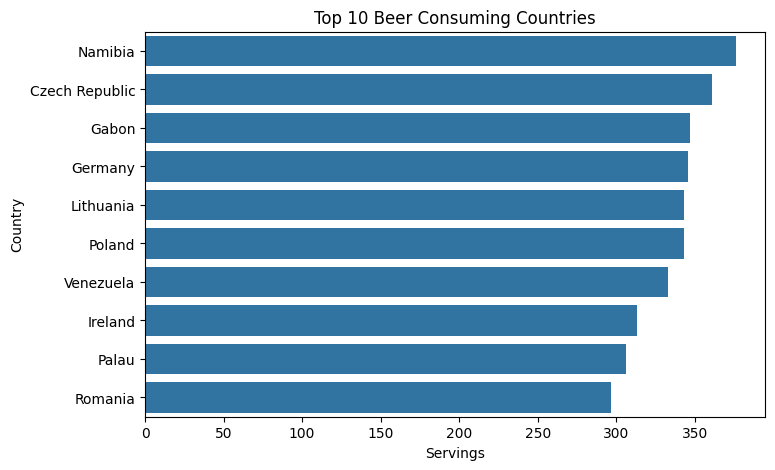

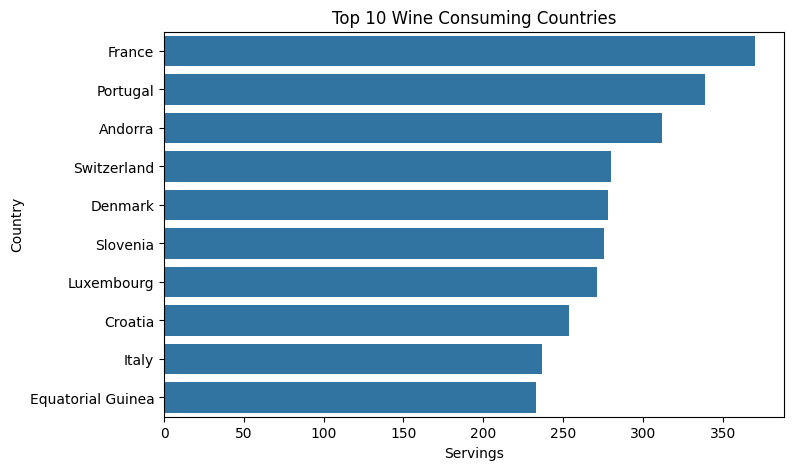

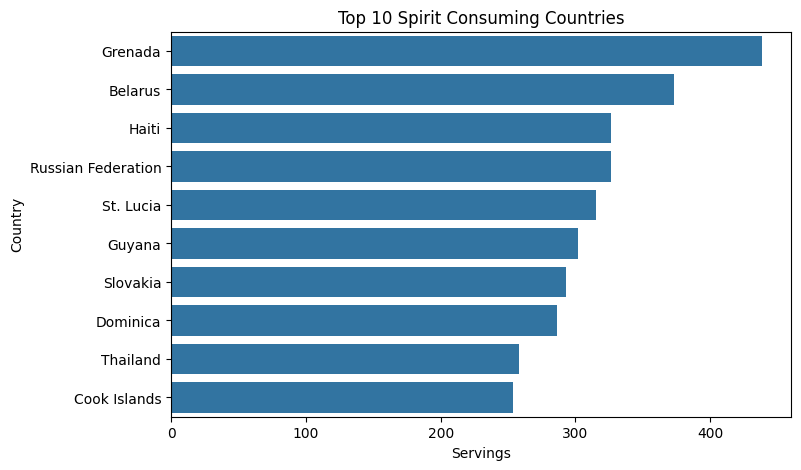

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.barplot(data=top_beer, x="servings", y="country")
plt.title("Top 10 Beer Consuming Countries")
plt.xlabel("Servings")
plt.ylabel("Country")
plt.show()
plt.figure(figsize=(8,5))
sns.barplot(data=top_wine, x="servings", y="country")
plt.title("Top 10 Wine Consuming Countries")
plt.xlabel("Servings")
plt.ylabel("Country")
plt.show()
plt.figure(figsize=(8,5))
sns.barplot(data=top_spirit, x="servings", y="country")
plt.title("Top 10 Spirit Consuming Countries")
plt.xlabel("Servings")
plt.ylabel("Country")
plt.show()

## Problem 3
Create a wide dataframe using `pivot_table` with the tidy dataframe from Problem 2

In [ ]:
wide = tidy.pivot_table(
    index="country",
    columns="drink",
    values="servings"
)
wide.head()

drink,beer,spirit,wine
country,,,
Afghanistan,0.0,0.0,0.0
Albania,89.0,132.0,54.0
Algeria,25.0,0.0,14.0
Andorra,245.0,138.0,312.0
Angola,217.0,57.0,45.0
